# Title: Nighttime Light and Human-Shark Interaction (Times & Zones) Zad2108

### Question: How does Nighttime Light, as an indicator of industrialization and ecosystem light pollution, influence the time and zone at which human-shark interactions happen?

### Background/Context:
For my final project, I am examining how nighttime light, as an indicator of industrialization and ecosystem light pollution, influences human-shark interactions. Researchers at the Shark Research and Conservation Program at the University of Miami Rosenstiel School of Marine, Atmospheric and Earth Science have found that exposure to artificial light at night can suppress malatonin levels in wild sharks, which can heighten shark stress in human shark interactions [(Udel, 2026)](https://phys.org/news/2026-02-urban-pollution-disrupts-nighttime-melatonin.html). 

To compare this relationship, I chose to look at Volusia County in Florida, United States, and Cumberland County in New South Wales, Australia. The United States and, by proxy, Florida experienced an industrial revolution before Australia, as reflected in their nighttime light sums over the years. In this sense, Florida would show a more consistent high nighttime sum from the start of the study data (1992) to the end (2024). I also picked Volusia County & Cumberland County since these areas are known for a high amount of human and shark interactions, with Volusia County  being considered the "shark bite capital of the world [(Helling, 2024)](https://nypost.com/2024/05/27/us-news/shark-attack-capital-of-the-world-named-and-its-in-the-us/) and New South Wales having a similar reputation [(Cooper, 2026)](https://www.abc.net.au/news/2026-01-21/what-australian-shark-attack-data-reveals/106248228).

### Hypotheses:

This leads to the hypothesis of this study with is that between 1992 and 2024, 1) Higher artificial light varibale is per time is associated with higher shark human interactions 2) Due to higher artificial light varibale occuring closer to shore, higher shark human interations will be associated with closeness to shore 3) As artifical light increases timing of human - shark interaction will shift to later in the night due to the distruption in sharks' melatonin & higher stress levels. 

### Datasets:
To accomplish this, I used the Global Shark Attack File and Google Earth Engine's [VNP46A2: VIIRS Lunar Gap-Filled BRDF Nighttime Lights Daily L3 Global 500m (2012-Present)](https://developers.google.com/earth-engine/datasets/catalog/NASA_VIIRS_002_VNP46A2) & [CCNL: Consistent and Corrected Nighttime Light Dataset from DMSP-OLS (1992-2013) v1](https://developers.google.com/earth-engine/datasets/catalog/BNU_FGS_CCNL_v1)

In the [Global Shark Attack File](https://www.sharkattackfile.net/incidentlog.html), I pulled the time (year, month, and hours & minutes) from the Shark Human Interaction column and manually reviewed the Human Activity during Shark Interaction columns, assigning a shore zone value to each. For Cumberland County, Shore Zones are Splash, Surf, and Post Surf, with the classifications below

Time: the original time was in military time, so I converted it to minutes and divided by 60 to get the hour as an integer.  

Post Surf Zone: activities that take place 100 meters+  (There were no shark interactions that fit this category in Volusia data)
- Any type of Fishing
- Wrangling sharks
- Any type of Boating
- Any type of Driving

Surf Zone: activities that take place 50 to 100 meters from the shoreline [(Brander, 2023)](https://www.theguardian.com/lifeandstyle/2023/oct/02/rivers-of-the-sea-how-far-from-shore-can-rips-really-take-you)
- Surfing

Splash Zone: activities that take place 0 to 50 meters from the shoreline
- Walking
- Wading
- Swimming
- Playing w/ balls
- Any type of boarding
  
Corrected Nighttime Light Dataset from DMSP-OLS (1992-2013) v1:
I pulled the annual average light-in-unit DN from the CCNL DMSP dataset, which represents the corrected nighttime light intensity (since the original dataset includes multiple satellites, it has multiple values per year). This dataset resolves this confusion. Pixel values range from 0 to 63; this was the previous scale used for measuring nighttime light data before VIIRS, and it ended in 2013.

VNP46A2: VIIRS Lunar Gap-Filled BRDF Nighttime Lights Daily L3 Global 500m (2012-Present):
I also pulled the monthly VIIRS VNOP46A2 Dataset for the monthly mean average radiance (nanowatts per square centimeter per steradian). This value removes artifacts from lunar, atmospheric, and BRDF (viewing-angle) effects, ensuring it reflects actual surface lighting (such as cities) rather than environmental factors. An algorithm to provide a clear daily image that measures the brightness of light, specifically, the amount of light emitted or reflected from a surface toward a sensor in a particular direction.

### Overall Plan:
- I will detrend the time to examine the raw effects of nighttime light on these units.
- My first figure will be a Scatterplot of Annually Shark Interaction Count over Annually Average Light (DMSP 1992-2013), Cumberland County (NSW, AUS) & Volusia County (Florida, USA), to visualize their relationship for each of the zones between shark interaction count and nighttime light
- My second figure will be a Linear plot of Monthly Shark Interaction Count Mean over Monthly Average Radiance (VIIRS 2012-2024), Cumberland County (NSW, AUS) & Volusia County (Florida, USA), since there is a lot of monthly data, and this more accurately shows their relationship for each of the zones between shark interaction count and nighttime light
- My third figure will be a Scatterplot of Annual Shark Interaction Count over Annual Average Radiance (VIIRS 2012-2024), Cumberland County (NSW, AUS) & Volusia County (Florida, USA), to see and compare it to the first figure's yjay uses DSMP data in its scatter plot and see if the relationship is similar for each of the zones between shark interaction count and night time light
- My fourth & fifth figure will be a Linear Regression of Annually Shark Interaction Time over Annually Average Light (DMSP 1992-2013), Cumberland County (NSW, AUS) & Volusia County (Florida, USA), for the following: SplashZone, SurfZone, Post SurfZone, and Overall, to see what the relationship for each of the zones and the overall relationship is between shark interaction time and nighttime light
- My sixth & seveth figure will be a Linear Regression of Annually Shark Interaction Time over Monthly Average Radiance: Overall (VIIRS 2012-2024), Cumberland County (NSW, AUS) & Volusia County (Florida, USA), for the following: SplashZone, SurfZone, Post SurfZone, and Overall, to see what the relationship for each of the zones and the overall relationship is between shark interaction time and nighttime light

### Cleaning Context:
I cleaned up the Data in a spreadsheet before uploading it by matching the DN & AVG_RAD units to their respective count & time units.

In [1]:
#Downloading Fundamentals + Seaborn
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Datasets

In [2]:
#loading in F1_CUMBER_CCNL_YR_ZONES_FIN & F1_VOLUSIA_CCNL_YR_ZONES_FIN
df1 = pd.read_csv('F1_CUMBER_CCNL_YR_ZONES_FIN.csv')
df2 = pd.read_csv('F1_VOLUSIA_CCNL_YR_ZONES_FIN.csv')

### Loading in F2_CUMBER_VIIRS_MO_ZONES_FIN & F2_VOLUSIA_VIIRS_MO_ZONES_FIN
df3 = pd.read_csv('F2_CUMBER_VIIRS_MO_ZONES_FIN.csv')
df4 = pd.read_csv('F2_VOLUSIA_VIIRS_MO_ZONES_FIN.csv')

# Loading in F3_CUMBER_CCNL_YR_TIME_FIN & F3_VOLUSIA_CCNL_YR_TIME_FIN
df7 = pd.read_csv('F3_CUMBER_CCNL_YR_TIME_FIN.csv')
df8 = pd.read_csv('F3_VOLUSIA_CCNL_YR_TIME_FIN.csv')

### Loading in F4_CUMBER_VIIRS_MO_TIME_FIN & F4_VOLUSIA_VIIRS_MO_TIME_FIN
df9 = pd.read_csv('F4_CUMBER_VIIRS_MO_TIME_FIN.csv')
df10 = pd.read_csv('F4_VOLUSIA_VIIRS_MO_TIME_FIN.csv')

In [3]:
#F1_CUMBER_CCNL_YR_ZONES_FIN Has yearly	YR_AVG_LIGHT_CORRECTED_DN for YR_SPLASHZONE_CT, YR_POSTSURF_CT and 
#YR_SURFZONE_CT for CUMBERLAND COUNTY, NSW, AUS 
df1

,YR,YR_AVG_LIGHT_CORRECTED_DN,YR_SPLASHZONE_CT,YR_POSTSURF_CT,YR_SURFZONE_CT
0,1992,7.578254,1,0,0
1,1993,8.006516,0,1,0
2,1996,9.006682,2,1,0
3,2011,9.406686,1,1,3
4,2000,9.682503,0,1,1
5,2012,9.723489,0,4,3
6,2001,9.811414,0,0,3
7,1998,9.961493,0,1,0
8,1994,10.051510,0,0,0
9,2002,10.118933,1,1,1


In [4]:
#F1_VOLUSIA_CCNL_YR_ZONES_FIN Has yearly YR_AVG_LIGHT_CORRECTED_DN for YR_SPLASHZONE_CT and 
#YR_SURFZONE_CT for VOLUSIA COUNTY, FLORIDA, USA 
df2

,YR,YR_AVG_LIGHT_CORRECTED_DN,YR_SPLASHZONE_CT,YR_SURFZONE_CT
0,1992,11.993788,1,0
1,1993,12.656753,1,0
2,1994,15.810548,1,4
3,1995,18.276943,4,7
4,1996,15.911304,5,2
5,1997,17.401346,7,5
6,1998,17.566972,0,7
7,1999,17.396513,4,3
8,2000,16.753034,11,2
9,2001,16.307128,7,16


In [5]:
#F2_CUMBER_VIIRS_MO_ZONES_FIN Has monthly MO_AVG_RAD_NW_CM2_SR for MO_SPLASHZONE_CT, MO_POSTSURF_CT and 
#MO_SPLASHZONE_CT for CUMBERLAND COUNTY, NSW, AUS
df3

,YR,MO,MO_AVG_RAD_NW_CM2_SR,MO_SPLASHZONE_CT,MO_POSTSURF_CT,MO_SURFZONE_CT
0,2012,1,2.846614,0,0,2
1,2012,2,2.773804,0,1,0
2,2012,3,2.788529,0,0,0
3,2012,4,3.052275,0,0,0
4,2012,5,2.886139,0,0,0
...,...,...,...,...,...,...
151,2024,8,3.991149,0,0,0
152,2024,9,3.864647,0,0,0
153,2024,10,3.603916,0,0,0
154,2024,11,4.316660,0,0,0


In [6]:
#F2_VOLUSIA_VIIRS_MO_ZONES_FIN Has monthly MO_AVG_RAD_NW_CM2_SR for MO_SPLASHZONE_CT and 
#MO_SPLASHZONE_CT for VOLUSIA COUNTY, FLORIDA, USA 
df4

,YR,MO,MO_AVG_RAD_NW_CM2_SR,MO_SPLASHZONE_CT,MO_SURFZONE_CT
0,2012,1,3.999018,0,0
1,2012,2,3.768194,0,0
2,2012,3,4.106525,0,3
3,2012,4,4.174099,0,0
4,2012,5,3.928773,0,0
...,...,...,...,...,...
151,2024,8,4.491356,0,0
152,2024,9,4.148854,0,0
153,2024,10,4.598789,0,0
154,2024,11,4.582620,0,0


In [7]:
#F3_CUMBER_CCNL_YR_TIME_FIN Has yearly YR_AVG_LIGHT_CORRECTED_DN for INTERACT_TIME and 
#SHOREZONE for CUMBERLAND COUNTY, NSW, AUS 
df7

,YR,SHOREZONE,INTERACT_TIME,YR_AVG_LIGHT_CORRECTED_DN
0,1996,SPLASHZONE,0.000000,9.006682
1,2011,SURFZONE,5.750000,9.406686
2,2003,SPLASHZONE,6.000000,10.766093
3,2011,SURFZONE,6.000000,9.406686
4,2005,SURFZONE,6.166667,12.680344
...,...,...,...,...
80,1998,POSTSURF,20.000000,9.961493
81,2012,SURFZONE,20.000000,9.723489
82,2007,SPLASHZONE,20.500000,11.115196
83,2002,SURFZONE,20.750000,10.118932


In [8]:
#F3_VOLUSIA_CCNL_YR_TIME_FIN Has yearly YR_AVG_LIGHT_CORRECTED_DN for INTERACT_TIME and 
#SHOREZONE for VOLUSIA COUNTY, FLORIDA, USA 
df8

,YR,SHOREZONE,INTERACT_TIME,YR_AVG_LIGHT_CORRECTED_DN
0,2007,SURFZONE,6.000000,19.089966
1,2011,SURFZONE,6.500000,17.209257
2,2007,SPLASHZONE,7.000000,19.089966
3,2000,SPLASHZONE,7.833333,16.753034
4,1994,SURFZONE,8.000000,15.810548
...,...,...,...,...
209,2009,SPLASHZONE,19.000000,18.786593
210,2010,SPLASHZONE,19.250000,17.460999
211,2001,SURFZONE,20.066667,16.307128
212,1998,SURFZONE,20.250000,17.566972


In [9]:
#F4_CUMBER_VIIRS_MO_TIME_FIN Has monthly MO_AVG_RAD_NW_CM2_SR for INTERACT_TIME and 
#SHOREZONE for CUMBERLAND COUNTY, NSW, AUS 
df9

,YR,MO,SHOREZONE,INTERACT_TIME,MO_AVG_RAD_NW_CM2_SR
0,12,2017,SURFZONE,0.0,3.100441
1,12,2016,POSTSURF,2.0,3.050209
2,7,2015,SURFZONE,6.0,2.694185
3,9,2017,SURFZONE,6.0,3.091122
4,11,2020,SURFZONE,6.0,3.174190
...,...,...,...,...,...
85,1,2021,SPLASHZONE,18.5,3.364732
86,3,2016,SURFZONE,19.0,2.997846
87,2,2018,SPLASHZONE,19.0,3.099724
88,1,2012,SURFZONE,20.0,2.846614


In [10]:
#F4_VOLUSIA_VIIRS_MO_TIME_FIN Has monthly MO_AVG_RAD_NW_CM2_SR for INTERACT_TIME and 
#SHOREZONE for VOLUSIA COUNTY, FLORIDA, USA 
df10

,YR,MO,SHOREZONE,INTERACT_TIME,MO_AVG_RAD_NW_CM2_SR
0,2019,7,SPLASHZONE,0.0,3.616951
1,2017,9,SURFZONE,2.0,3.426077
2,2016,4,SURFZONE,6.0,3.544630
3,2018,9,SURFZONE,6.0,3.476074
4,2022,3,SURFZONE,6.0,4.215065
...,...,...,...,...,...
78,2020,3,SURFZONE,18.5,4.090891
79,2022,3,SURFZONE,18.5,4.215065
80,2016,12,SURFZONE,19.0,3.786160
81,2019,8,SURFZONE,19.0,3.553099


### Figure 1: Scatterplot of Annually Shark Interaction Count over Annually Average Light (DMSP 1992-2013), Cumberland County (NSW, AUS) & Volusia County (Florida, USA)

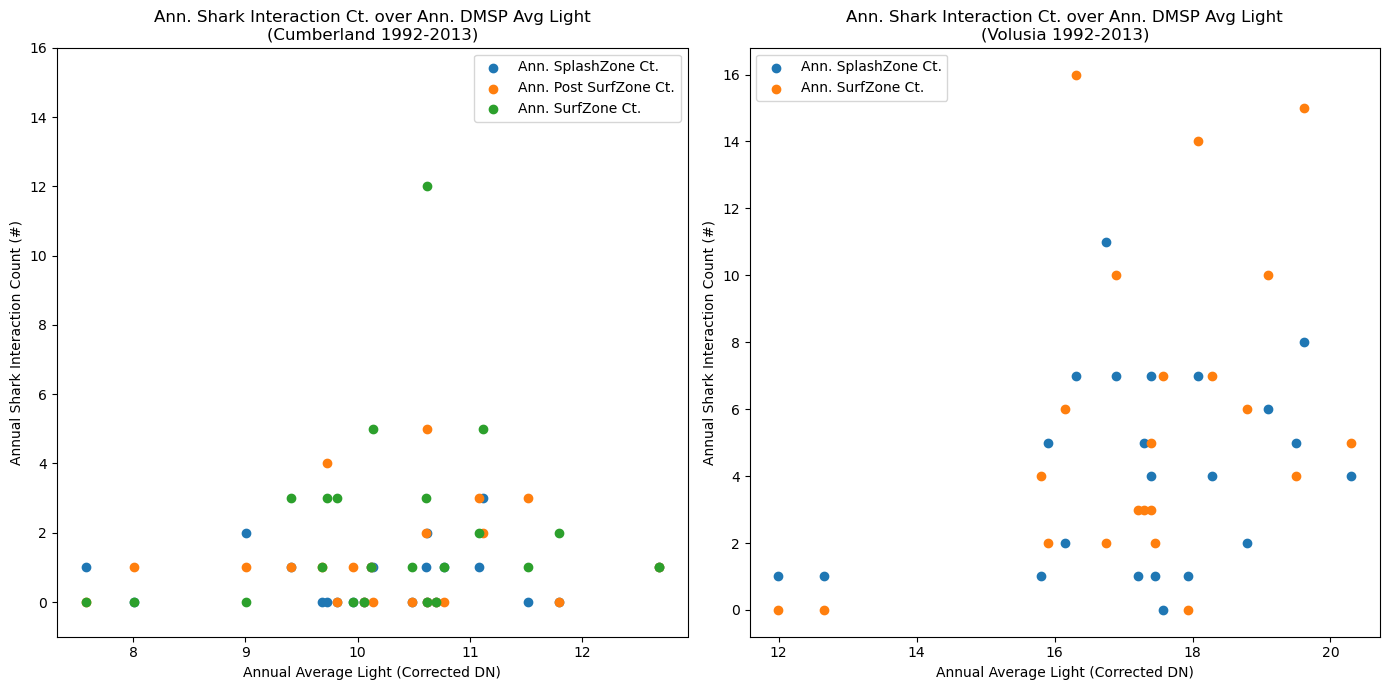

In [11]:
# visualizing the data by plotting two scatter plot figures of data 
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].scatter(df1.YR_AVG_LIGHT_CORRECTED_DN, df1.YR_SPLASHZONE_CT, label = 'Ann. SplashZone Ct.')
axes[0].scatter(df1.YR_AVG_LIGHT_CORRECTED_DN, df1.YR_POSTSURF_CT, label = 'Ann. Post SurfZone Ct.')
axes[0].scatter(df1.YR_AVG_LIGHT_CORRECTED_DN, df1.YR_SURFZONE_CT, label = 'Ann. SurfZone Ct.')
axes[0].legend(loc='upper right',fontsize=10)
axes[0].set_title('Ann. Shark Interaction Ct. over Ann. DMSP Avg Light\n(Cumberland 1992-2013)')
axes[0].set_xlabel('Annual Average Light (Corrected DN)')
axes[0].set_ylabel('Annual Shark Interaction Count (#)')
axes[0].set_ylim(-1,16)

axes[1].scatter(df2.YR_AVG_LIGHT_CORRECTED_DN, df2.YR_SPLASHZONE_CT, label = 'Ann. SplashZone Ct.')
axes[1].scatter(df2.YR_AVG_LIGHT_CORRECTED_DN, df2.YR_SURFZONE_CT, label = 'Ann. SurfZone Ct.')
axes[1].legend(loc='upper left',fontsize=10)
axes[1].set_title('Ann. Shark Interaction Ct. over Ann. DMSP Avg Light\n(Volusia 1992-2013)')
axes[1].set_xlabel('Annual Average Light (Corrected DN)')
axes[1].set_ylabel('Annual Shark Interaction Count (#)')

plt.tight_layout()
plt.show()

### F1: Discussion
In both graphs, there seems to be a positive  relationship between shark attack counts across all shore zones and annual average light DN nighttime light, with more shark-human interactions happening with  more nighttime light. In Cumberland, there seems to be a more normal distribution, with Volusia showing a left skew. These results align with the hypothesis that more nighttime light may increase shark-human interactions

In [12]:
# using groupby to get the mean of MO_AVG_RAD_NW_CM2_SR for each zonal group since the data is skewed towards lower
# values this nominalizes the data and helps represent the data better, which is what the lights are associated with
# each frequency of interactions


splash1 = df3.groupby('MO_SPLASHZONE_CT').mean('MO_AVG_RAD_NW_CM2_SR').reset_index(drop = True)
splash1['MO_SPLASHZONE_CT'] = np.arange(0,3)

postsurf1 = df3.groupby('MO_POSTSURF_CT').mean('MO_AVG_RAD_NW_CM2_SR').reset_index(drop = True)
postsurf1['MO_POSTSURF_CT'] = np.arange(0,3)

surf1 = df3.groupby('MO_SURFZONE_CT').mean('MO_AVG_RAD_NW_CM2_SR').reset_index(drop = True)
surf1['MO_SURFZONE_CT'] = np.arange(0,4)

splash2 = df4.groupby('MO_SPLASHZONE_CT').mean('MO_AVG_RAD_NW_CM2_SR').reset_index(drop = True)
splash2['MO_SPLASHZONE_CT'] = np.arange(0,4)

surf2 = df4.groupby('MO_SURFZONE_CT').mean('MO_AVG_RAD_NW_CM2_SR')
surf2['MO_SURFZONE_CT'] = np.arange(0,4)

### Figure 2: Linear plot of Monthly Shark Interaction Count Mean over Monthly Average Radiance (VIIRS 2012-2024), Cumberland County (NSW, AUS) & Volusia County (Florida, USA)

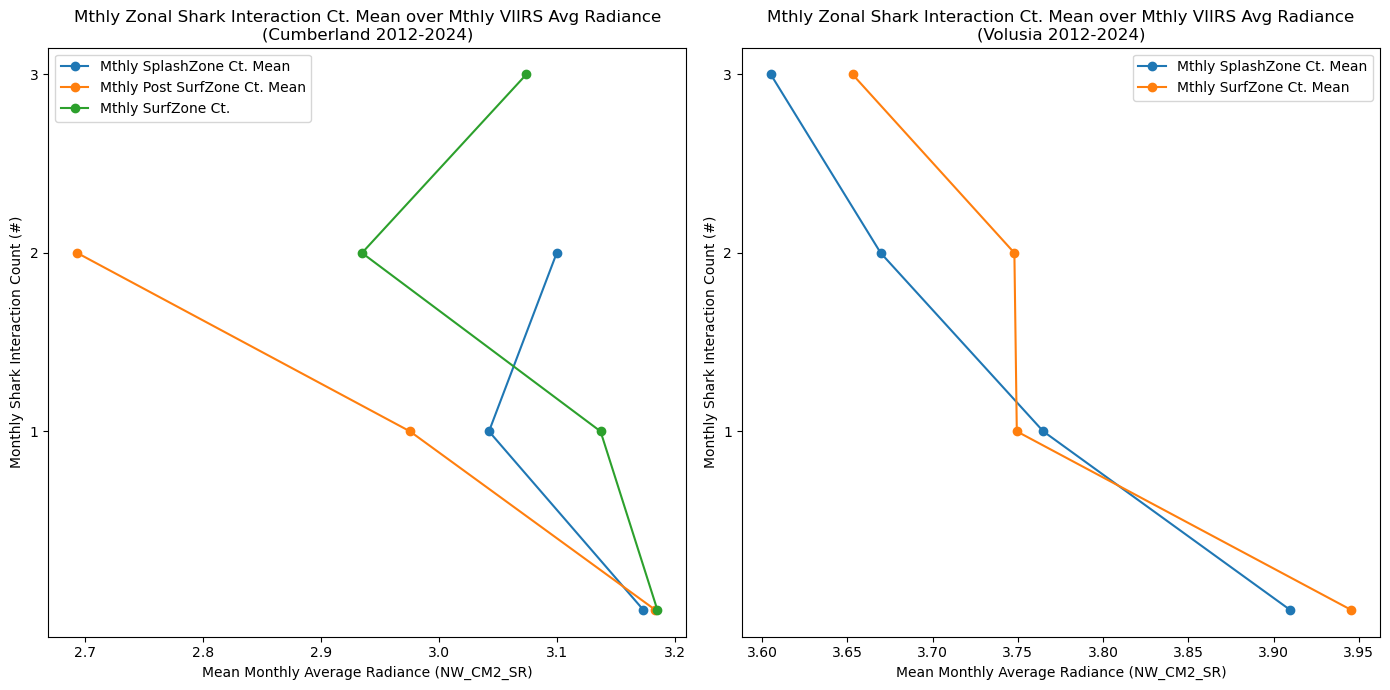

In [23]:
#ploting two plot figures of data putting the 
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].plot(splash1.MO_AVG_RAD_NW_CM2_SR, splash1.MO_SPLASHZONE_CT, marker = 'o', label = 'Mthly SplashZone Ct. Mean')
axes[0].plot(postsurf1.MO_AVG_RAD_NW_CM2_SR, postsurf1.MO_POSTSURF_CT, marker = 'o', label = 'Mthly Post SurfZone Ct. Mean')
axes[0].plot(surf1.MO_AVG_RAD_NW_CM2_SR, surf1.MO_SURFZONE_CT, marker = 'o', label = 'Mthly SurfZone Ct.')
axes[0].legend(loc='upper left',fontsize=10)
axes[0].set_title('Mthly Zonal Shark Interaction Ct. Mean over Mthly VIIRS Avg Radiance\n(Cumberland 2012-2024)')
axes[0].set_xlabel('Mean Monthly Average Radiance (NW_CM2_SR)')
axes[0].set_ylabel('Monthly Shark Interaction Count (#)')
axes[0].set_yticks([1, 2, 3])

axes[1].plot(splash2.MO_AVG_RAD_NW_CM2_SR, splash2.MO_SPLASHZONE_CT, marker = 'o', label = 'Mthly SplashZone Ct. Mean')
axes[1].plot(surf2.MO_AVG_RAD_NW_CM2_SR, surf2.MO_SURFZONE_CT, marker = 'o', label = 'Mthly SurfZone Ct. Mean')
axes[1].legend(loc='upper right',fontsize=10)
axes[1].set_title('Mthly Zonal Shark Interaction Ct. Mean over Mthly VIIRS Avg Radiance\n(Volusia 2012-2024)')
axes[1].set_xlabel('Mean Monthly Average Radiance (NW_CM2_SR)')
axes[1].set_ylabel('Monthly Shark Interaction Count (#)')
axes[1].set_yticks([1, 2, 3])

plt.tight_layout()
plt.show()

### F2: Discussion
Here we see that, for both regions, there seems to be a negative relationship between mean monthly average radiance nighttime light and shark interactions, with the mean of the zones decreasing as the shark attack count increases across all zones. In Cumberland, we see this more pronounced in the post-surfzone and less pronounced in the splashzone & surfzone; in Volusia, the splash & surf zones have a similar relationship. Overall, these results don't support the hypothesis that more nighttime light may increase shark-human interactions, and the discrepancy between these figures and the first one may be due to the use of different units.

In [14]:
# I am interested in what the annual data looks like for the VIIRS data and how it compares to the DSMP Data
# so I am taking the mean of the years and pairing with the sum of shark interactions in the monthly VIIRS data
# to see what each frequency is associated with what nighttime light data

#Using group by to get the mean of yearly MO_AVG_RAD_NW_CM2_SR
CUMBER_YRLY_AVG_RAD_NW_CM2_SR = df3.groupby('YR').mean()
CUMBER_YRLY_AVG_RAD_NW_CM2_SR['YR'] = np.arange(0,13)
VOLUSIA_YRLY_AVG_RAD_NW_CM2_SR = df4.groupby('YR').mean()
VOLUSIA_YRLY_AVG_RAD_NW_CM2_SR['YR'] = np.arange(0,13)

#Using group by to get the sum of each of the zonal counts 
CUMBER_CT = df3.groupby('YR').sum()
CUMBER_CT['YR'] = np.arange(0,13)
VOLUSIA_CT = df4.groupby('YR').sum()
VOLUSIA_CT['YR'] = np.arange(0,13)

### Figure 3: Scatterplot of Annual Shark Interaction Count over Annual Average Radiance (VIIRS 2012-2024), Cumberland County (NSW, AUS) & Volusia County (Florida, USA)

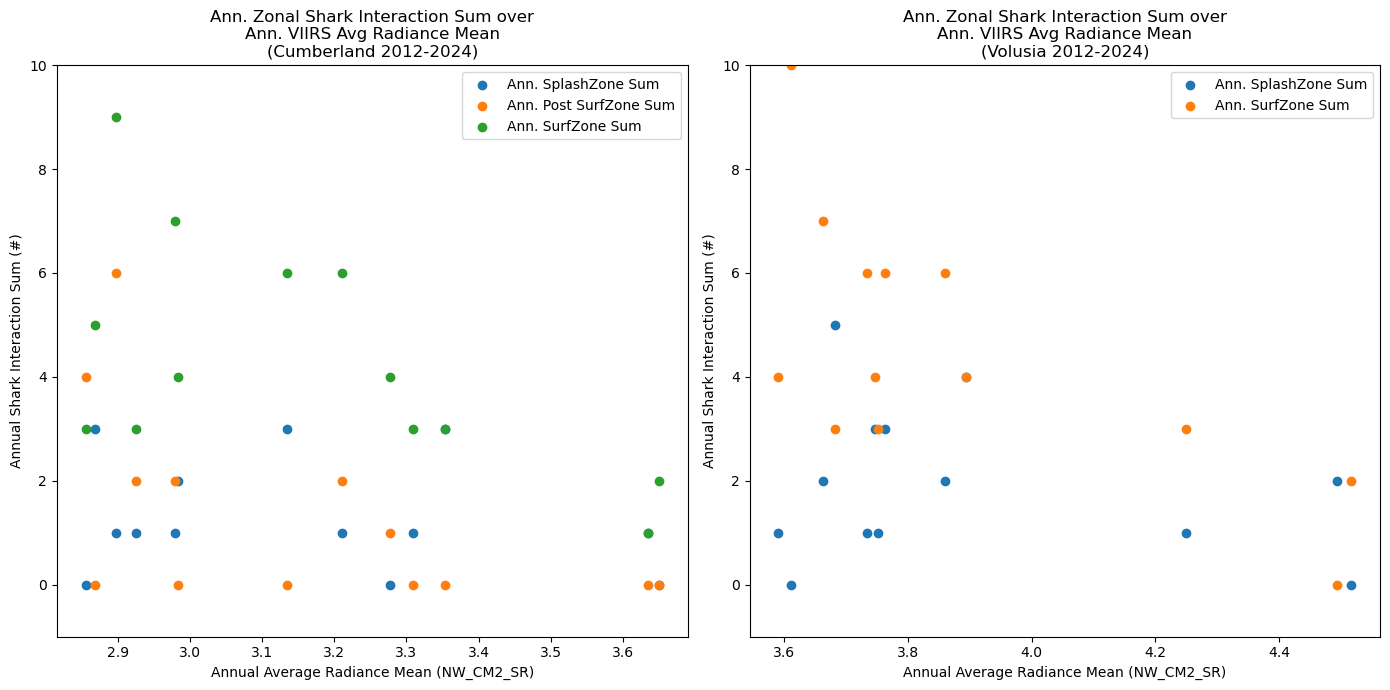

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].scatter(CUMBER_YRLY_AVG_RAD_NW_CM2_SR.MO_AVG_RAD_NW_CM2_SR, CUMBER_CT.MO_SPLASHZONE_CT, label = 'Ann. SplashZone Sum')
axes[0].scatter(CUMBER_YRLY_AVG_RAD_NW_CM2_SR.MO_AVG_RAD_NW_CM2_SR, CUMBER_CT.MO_POSTSURF_CT, label = 'Ann. Post SurfZone Sum')
axes[0].scatter(CUMBER_YRLY_AVG_RAD_NW_CM2_SR.MO_AVG_RAD_NW_CM2_SR, CUMBER_CT.MO_SURFZONE_CT, label = 'Ann. SurfZone Sum')
axes[0].legend(loc='upper right',fontsize=10)
axes[0].set_title('Ann. Zonal Shark Interaction Sum over\nAnn. VIIRS Avg Radiance Mean\n(Cumberland 2012-2024)')
axes[0].set_xlabel('Annual Average Radiance Mean (NW_CM2_SR)')
axes[0].set_ylabel('Annual Shark Interaction Sum (#)')
axes[0].set_ylim(-1,10)

axes[1].scatter(VOLUSIA_YRLY_AVG_RAD_NW_CM2_SR.MO_AVG_RAD_NW_CM2_SR, VOLUSIA_CT.MO_SPLASHZONE_CT, label = 'Ann. SplashZone Sum')
axes[1].scatter(VOLUSIA_YRLY_AVG_RAD_NW_CM2_SR.MO_AVG_RAD_NW_CM2_SR, VOLUSIA_CT.MO_SURFZONE_CT, label = 'Ann. SurfZone Sum')
axes[1].legend(loc='upper right',fontsize=10)
axes[1].set_title('Ann. Zonal Shark Interaction Sum over\nAnn. VIIRS Avg Radiance Mean\n(Volusia 2012-2024)')
axes[1].set_xlabel('Annual Average Radiance Mean (NW_CM2_SR)')
axes[1].set_ylabel('Annual Shark Interaction Sum (#)')
axes[1].set_ylim(-1,10)

plt.tight_layout()
plt.show()

### F3: Discussion
Here we see that, for both regions, there seems to be a negative relationship between annual average nighttime light radiance and shark interactions, with the annual sum of the shark interaction zones decreasing as the shark attack count increases across all zones. In Cumberland & Volusia, there is a pronounced right skew of the data for all zones. The Annual VIIRS data show the opposite relationship to the Annual DSMP CCNL nighttime light data for shark interaction counts: lower average nighttime light radiance is associated with higher shark interaction counts across all zones. The discrepancy between these figures and the first one may be due to the use of different units. Overall, these results don't support the hypothesis that more nighttime light may increase shark-human interactions, and the discrepancy between these figures and the first one may be due to the use of different units.


In [16]:

# Also using the loc function to make separate data frames for each of the zones since sns. needs to have a df to 
# refer to, I am doing linear regressions to see if the times of interactions are shifting in a certain direction 
# with changes in nighttime light.

df71 = df7.loc[df7['SHOREZONE'] == 'SPLASHZONE', ['INTERACT_TIME', 'YR_AVG_LIGHT_CORRECTED_DN']]
df72 = df7.loc[df7['SHOREZONE'] == 'SURFZONE', ['INTERACT_TIME', 'YR_AVG_LIGHT_CORRECTED_DN']]
df73 = df7.loc[df7['SHOREZONE'] == 'POSTSURF', ['INTERACT_TIME', 'YR_AVG_LIGHT_CORRECTED_DN']]

df81 = df8.loc[df8['SHOREZONE'] == 'SPLASHZONE', ['INTERACT_TIME', 'YR_AVG_LIGHT_CORRECTED_DN']]
df82 = df8.loc[df8['SHOREZONE'] == 'SURFZONE', ['INTERACT_TIME', 'YR_AVG_LIGHT_CORRECTED_DN']]

### Figure 4: Linear Regression of Annually Shark Interaction Time over Annually Average Light (DMSP 1992-2013) Cumberland County (NSW, AUS): Overall, SplashZone, SurfZone & Post SurfZone

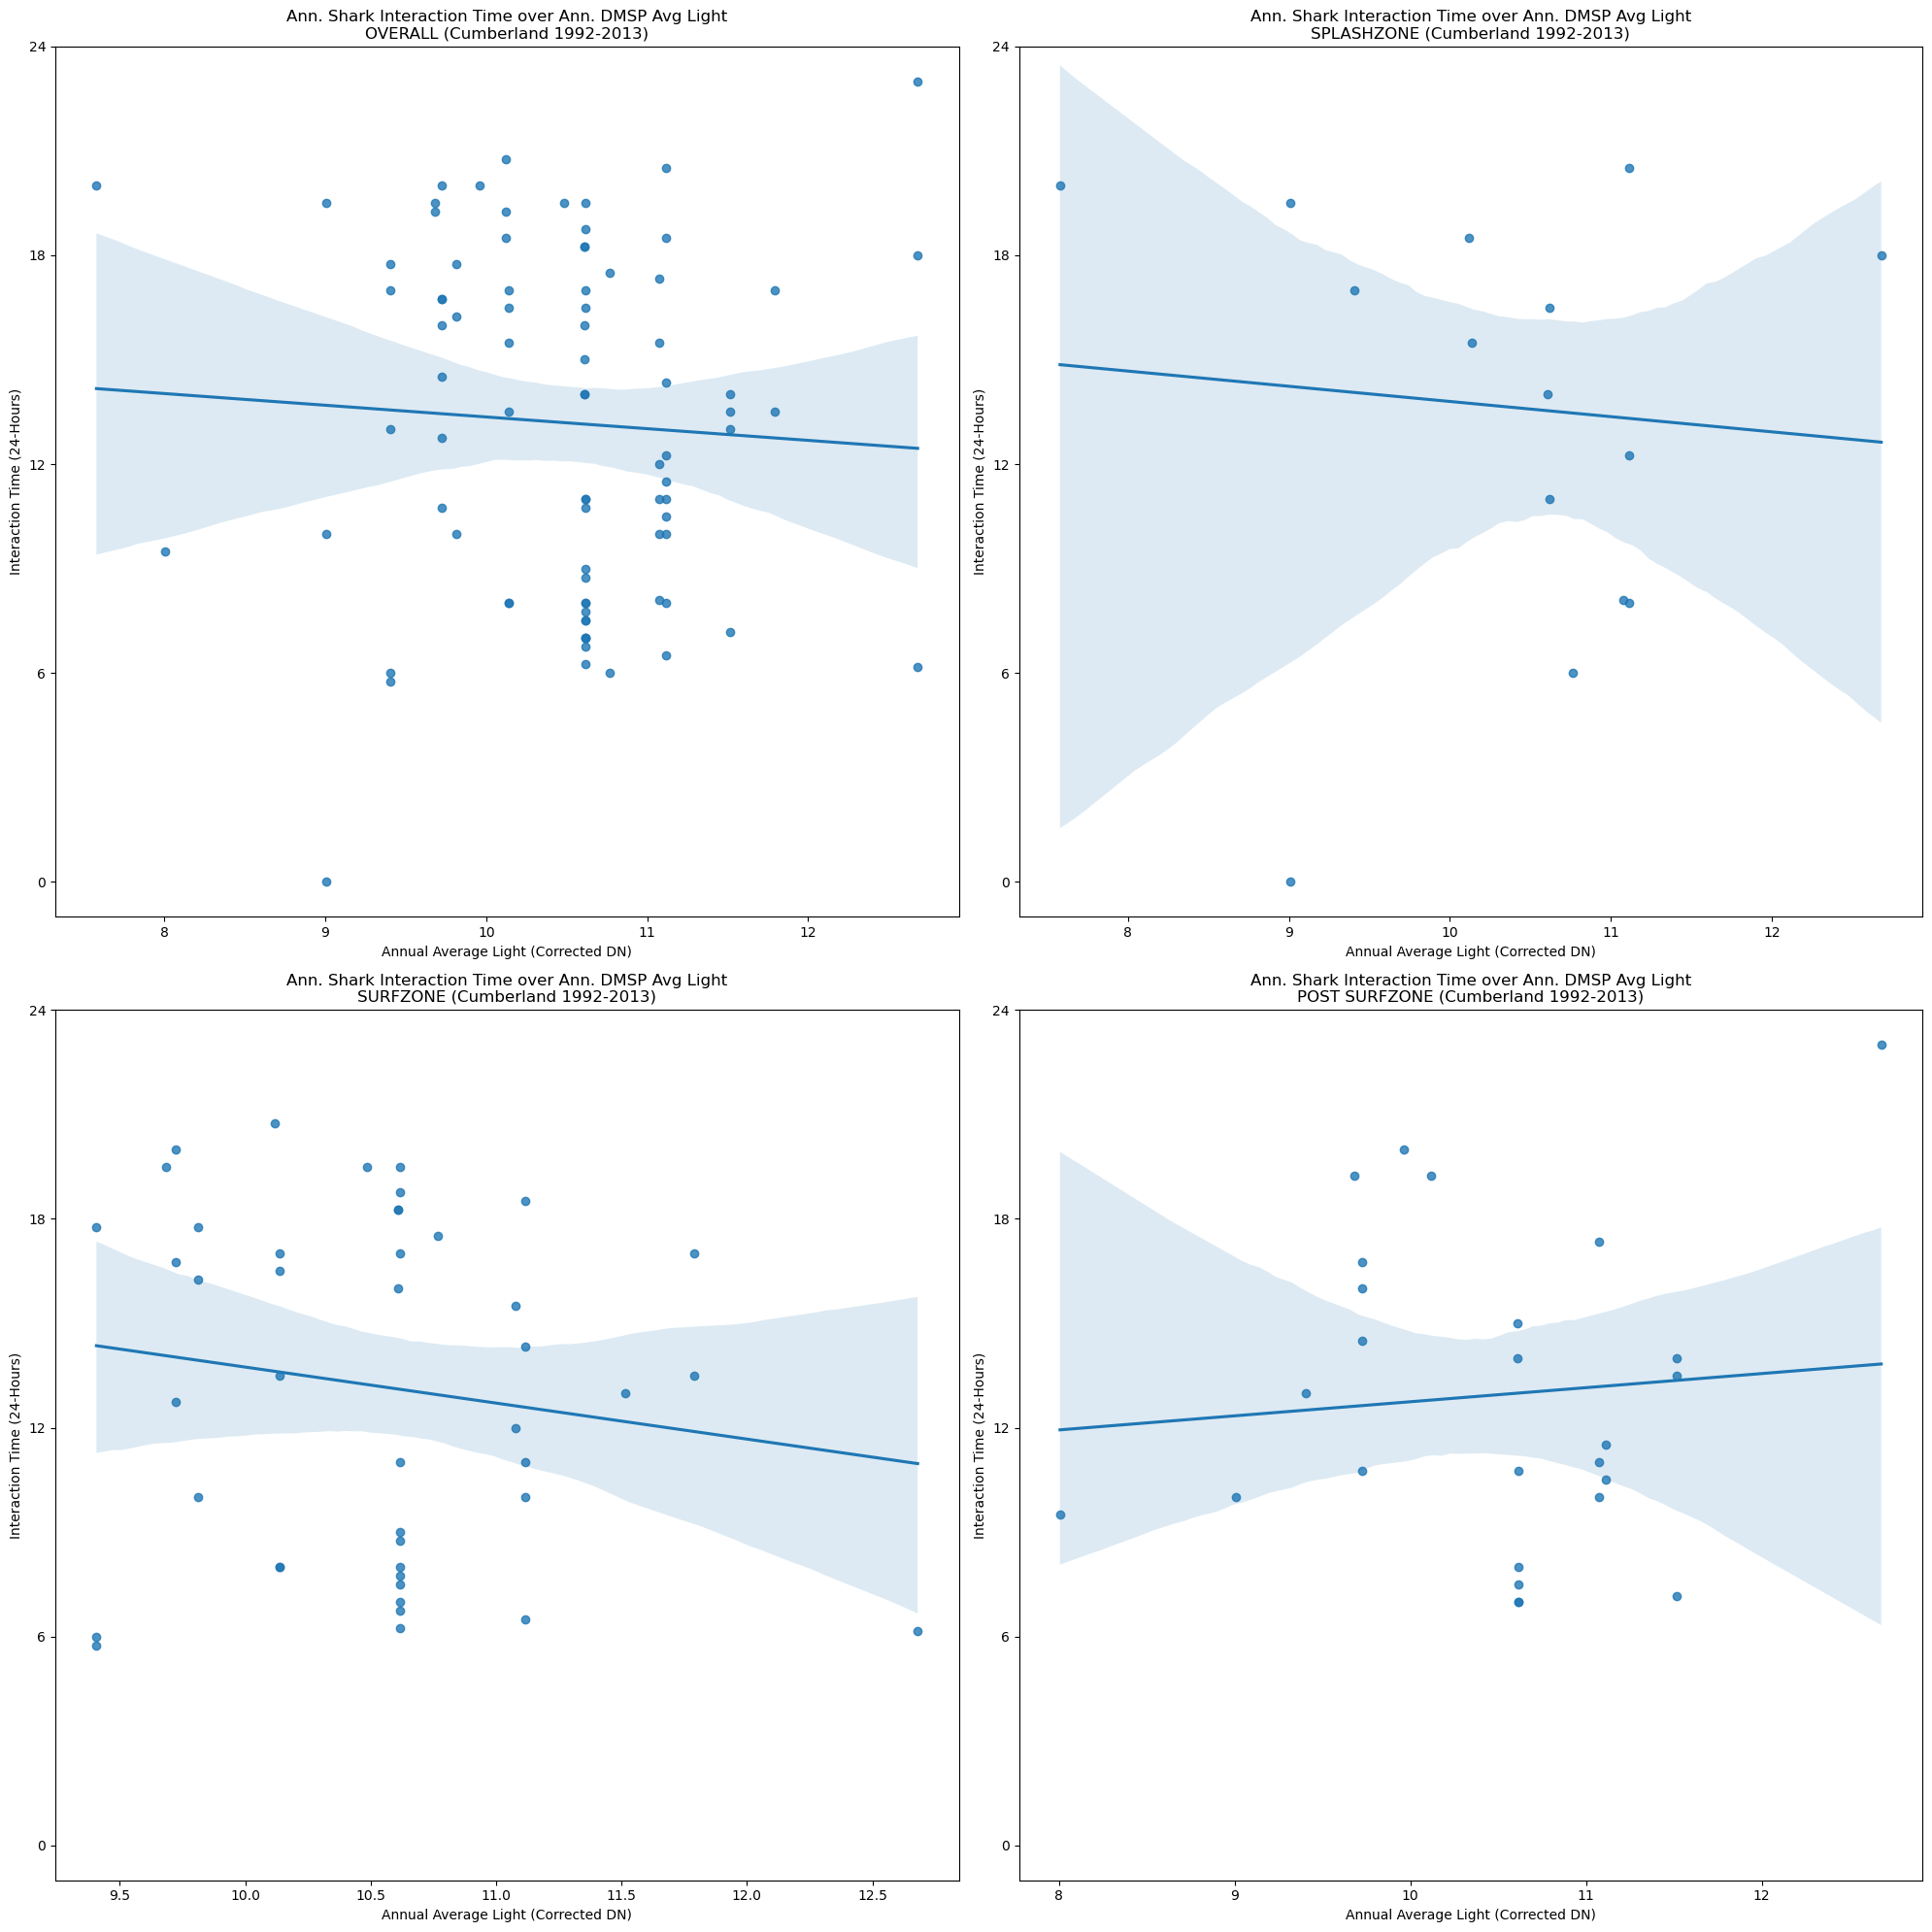

In [17]:
# plotting 4 linear regressions using loc that made separate dataframes for seaborn
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
sns.regplot(data = df7, x = 'YR_AVG_LIGHT_CORRECTED_DN', y = 'INTERACT_TIME', ax=axes[0,0])
axes[0,0].set_title('Ann. Shark Interaction Time over Ann. DMSP Avg Light\nOVERALL (Cumberland 1992-2013)')
axes[0,0].set_xlabel('Annual Average Light (Corrected DN)')
axes[0,0].set_ylabel('Interaction Time (24-Hours)')
axes[0,0].set_ylim(-1,24)
axes[0,0].set_yticks([0, 6, 12, 18, 24])

sns.regplot(data = df71, x = 'YR_AVG_LIGHT_CORRECTED_DN', y = 'INTERACT_TIME', ax=axes[0,1])
axes[0,1].set_title('Ann. Shark Interaction Time over Ann. DMSP Avg Light\nSPLASHZONE (Cumberland 1992-2013)')
axes[0,1].set_xlabel('Annual Average Light (Corrected DN)')
axes[0,1].set_ylabel('Interaction Time (24-Hours)')
axes[0,1].set_ylim(-1,24)
axes[0,1].set_yticks([0, 6, 12, 18, 24])

sns.regplot(data = df72, x = 'YR_AVG_LIGHT_CORRECTED_DN', y = 'INTERACT_TIME', ax=axes[1,0])
axes[1,0].set_title('Ann. Shark Interaction Time over Ann. DMSP Avg Light\nSURFZONE (Cumberland 1992-2013)')
axes[1,0].set_xlabel('Annual Average Light (Corrected DN)')
axes[1,0].set_ylabel('Interaction Time (24-Hours)')
axes[1,0].set_ylim(-1,24)
axes[1,0].set_yticks([0, 6, 12, 18, 24])

sns.regplot(data = df73, x = 'YR_AVG_LIGHT_CORRECTED_DN', y = 'INTERACT_TIME', ax=axes[1,1])
axes[1,1].set_title('Ann. Shark Interaction Time over Ann. DMSP Avg Light\nPOST SURFZONE (Cumberland 1992-2013)')
axes[1,1].set_xlabel('Annual Average Light (Corrected DN)')
axes[1,1].set_ylabel('Interaction Time (24-Hours)')
axes[1,1].set_ylim(-1,24)
axes[1,1].set_yticks([0, 6, 12, 18, 24])

plt.tight_layout()
plt.show()

### F4: Dicussion 
The SplashZone & SurfZone have a slight negative linear relationship, with interactions occurring earlier in the day as annual DN nighttime light increases, while the post-surfzone has a positive relationship, with interactions occurring later in the day as nighttime light increases. The overall relationship is a negative linear relationship, with interactions occurring early in the day as nighttime light increases, which does not align with our hypothesis that increased nighttime light shifts into the evening

### Figure 5: Linear Regression of Annually Shark Interaction Time over Annually Average Light (DMSP 1992-2013) Volusia County (Florida, USA): Overall, SplashZone & SurfZone

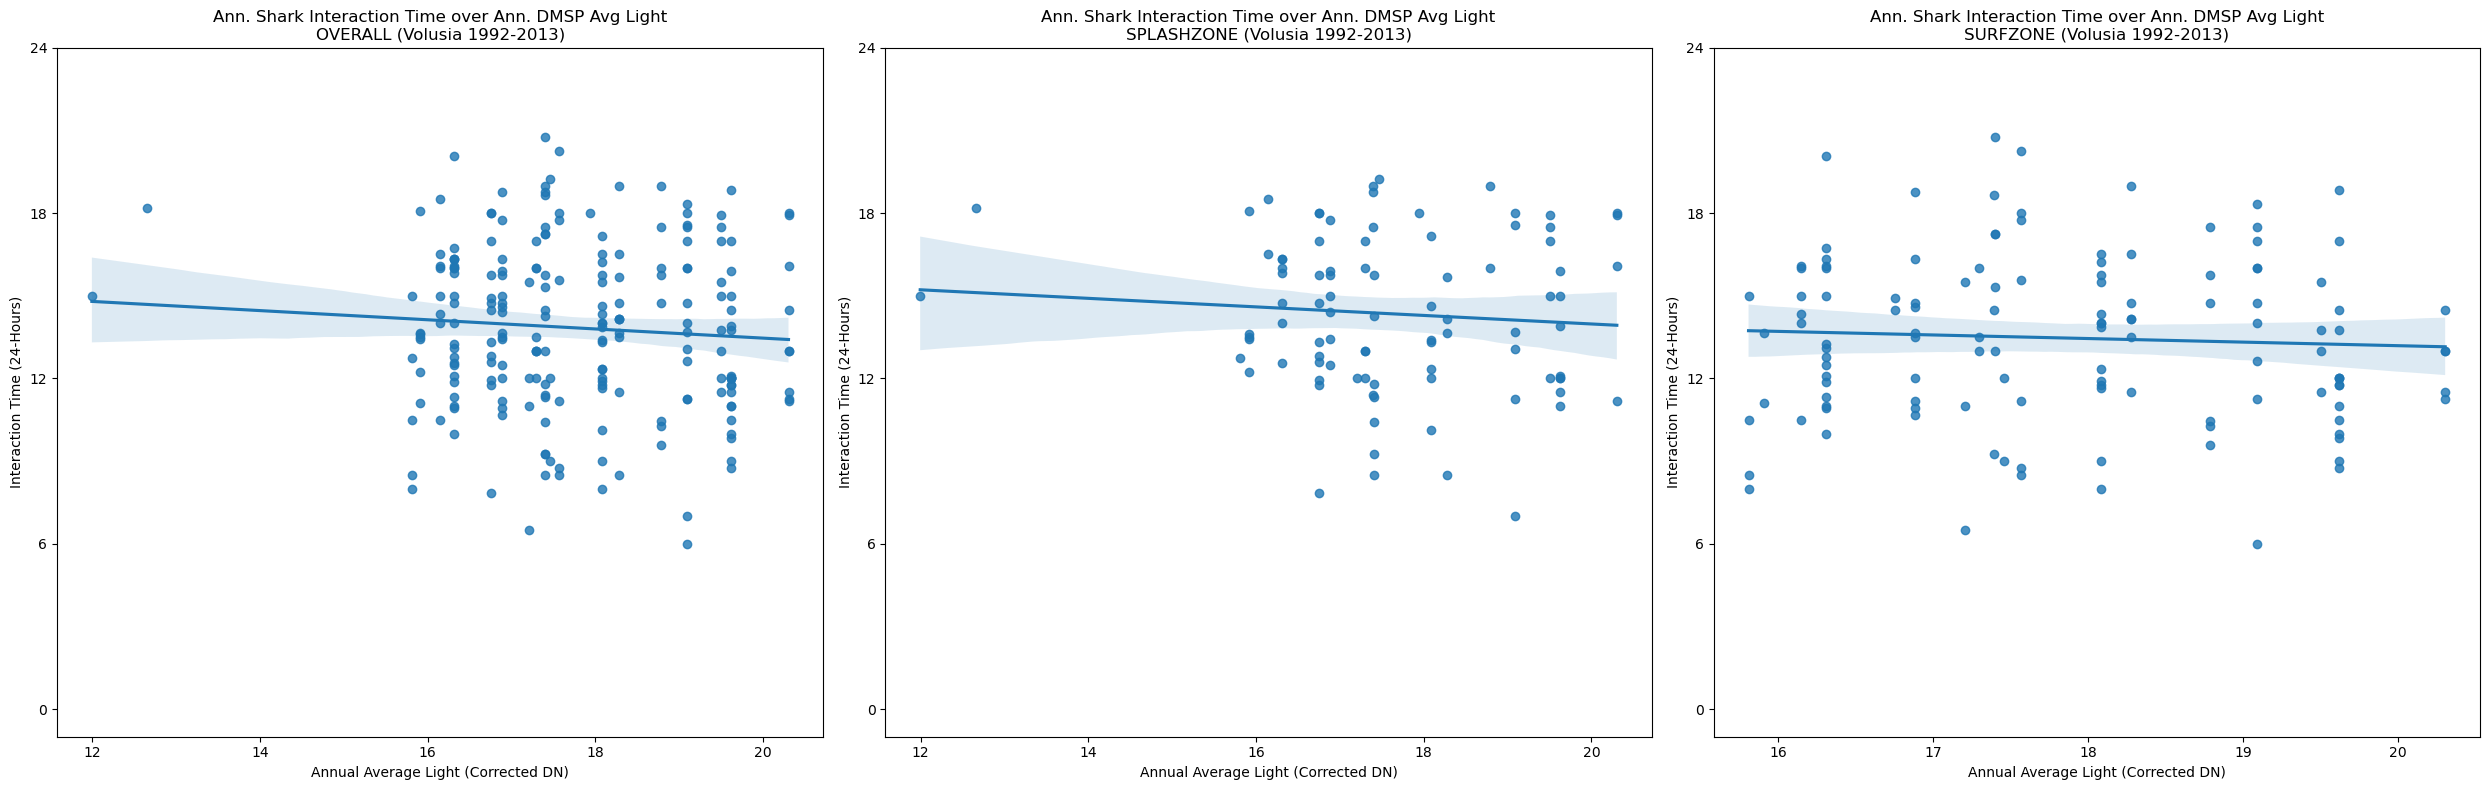

In [18]:
# plotting 4 linear regressions using loc that made separate dataframes for seaborn
fig, axes = plt.subplots(1, 3, figsize=(25, 8))
sns.regplot(data = df8, x = 'YR_AVG_LIGHT_CORRECTED_DN', y = 'INTERACT_TIME', ax=axes[0])
axes[0].set_title('Ann. Shark Interaction Time over Ann. DMSP Avg Light\nOVERALL (Volusia 1992-2013)')
axes[0].set_xlabel('Annual Average Light (Corrected DN)')
axes[0].set_ylabel('Interaction Time (24-Hours)')
axes[0].set_ylim(-1,24)
axes[0].set_yticks([0, 6, 12, 18, 24])


sns.regplot(data = df81, x = 'YR_AVG_LIGHT_CORRECTED_DN', y = 'INTERACT_TIME', ax=axes[1])
axes[1].set_title('Ann. Shark Interaction Time over Ann. DMSP Avg Light\nSPLASHZONE (Volusia 1992-2013)')
axes[1].set_xlabel('Annual Average Light (Corrected DN)')
axes[1].set_ylabel('Interaction Time (24-Hours)')
axes[1].set_ylim(-1,24)
axes[1].set_yticks([0, 6, 12, 18, 24])


sns.regplot(data = df82, x = 'YR_AVG_LIGHT_CORRECTED_DN', y = 'INTERACT_TIME', ax=axes[2])
axes[2].set_title('Ann. Shark Interaction Time over Ann. DMSP Avg Light\nSURFZONE (Volusia 1992-2013)')
axes[2].set_xlabel('Annual Average Light (Corrected DN)')
axes[2].set_ylabel('Interaction Time (24-Hours)')
axes[2].set_ylim(-1,24)
axes[2].set_yticks([0, 6, 12, 18, 24])

plt.tight_layout()
plt.show()

### F5: Dicussion 
Overall, SplashZone & SurfZone have a slight negative linear relationship, with interactions occurring earlier in the day as annual DN nighttime light increases. This does not align with our hypothesis that increased nighttime light shifts act in the evening, and it also shows a very weak relationship.

In [19]:
# Also using the loc function to make separate data frames for each of the zones since sns. needs to have a df to 
# refer to, I am doing linear regressions to see if the times of interactions are shifting in a certain direction 
# with changes in nighttime light.

df91 = df9.loc[df9['SHOREZONE'] == 'SPLASHZONE', ['INTERACT_TIME', 'MO_AVG_RAD_NW_CM2_SR']]
df92 = df9.loc[df9['SHOREZONE'] == 'SURFZONE', ['INTERACT_TIME', 'MO_AVG_RAD_NW_CM2_SR']]
df93 = df9.loc[df9['SHOREZONE'] == 'POSTSURF', ['INTERACT_TIME', 'MO_AVG_RAD_NW_CM2_SR']]

df101 = df10.loc[df10['SHOREZONE'] == 'SPLASHZONE', ['INTERACT_TIME', 'MO_AVG_RAD_NW_CM2_SR']]
df102 = df10.loc[df10['SHOREZONE'] == 'SURFZONE', ['INTERACT_TIME', 'MO_AVG_RAD_NW_CM2_SR']]

### Figure 6: Linear Regression of Monthly Shark Interaction Time over Monthly Average Radiance (VIIRS 2012-2024) Cumberland County (NSW, AUS): Overall, SplashZone, SurfZone & Post SurfZone

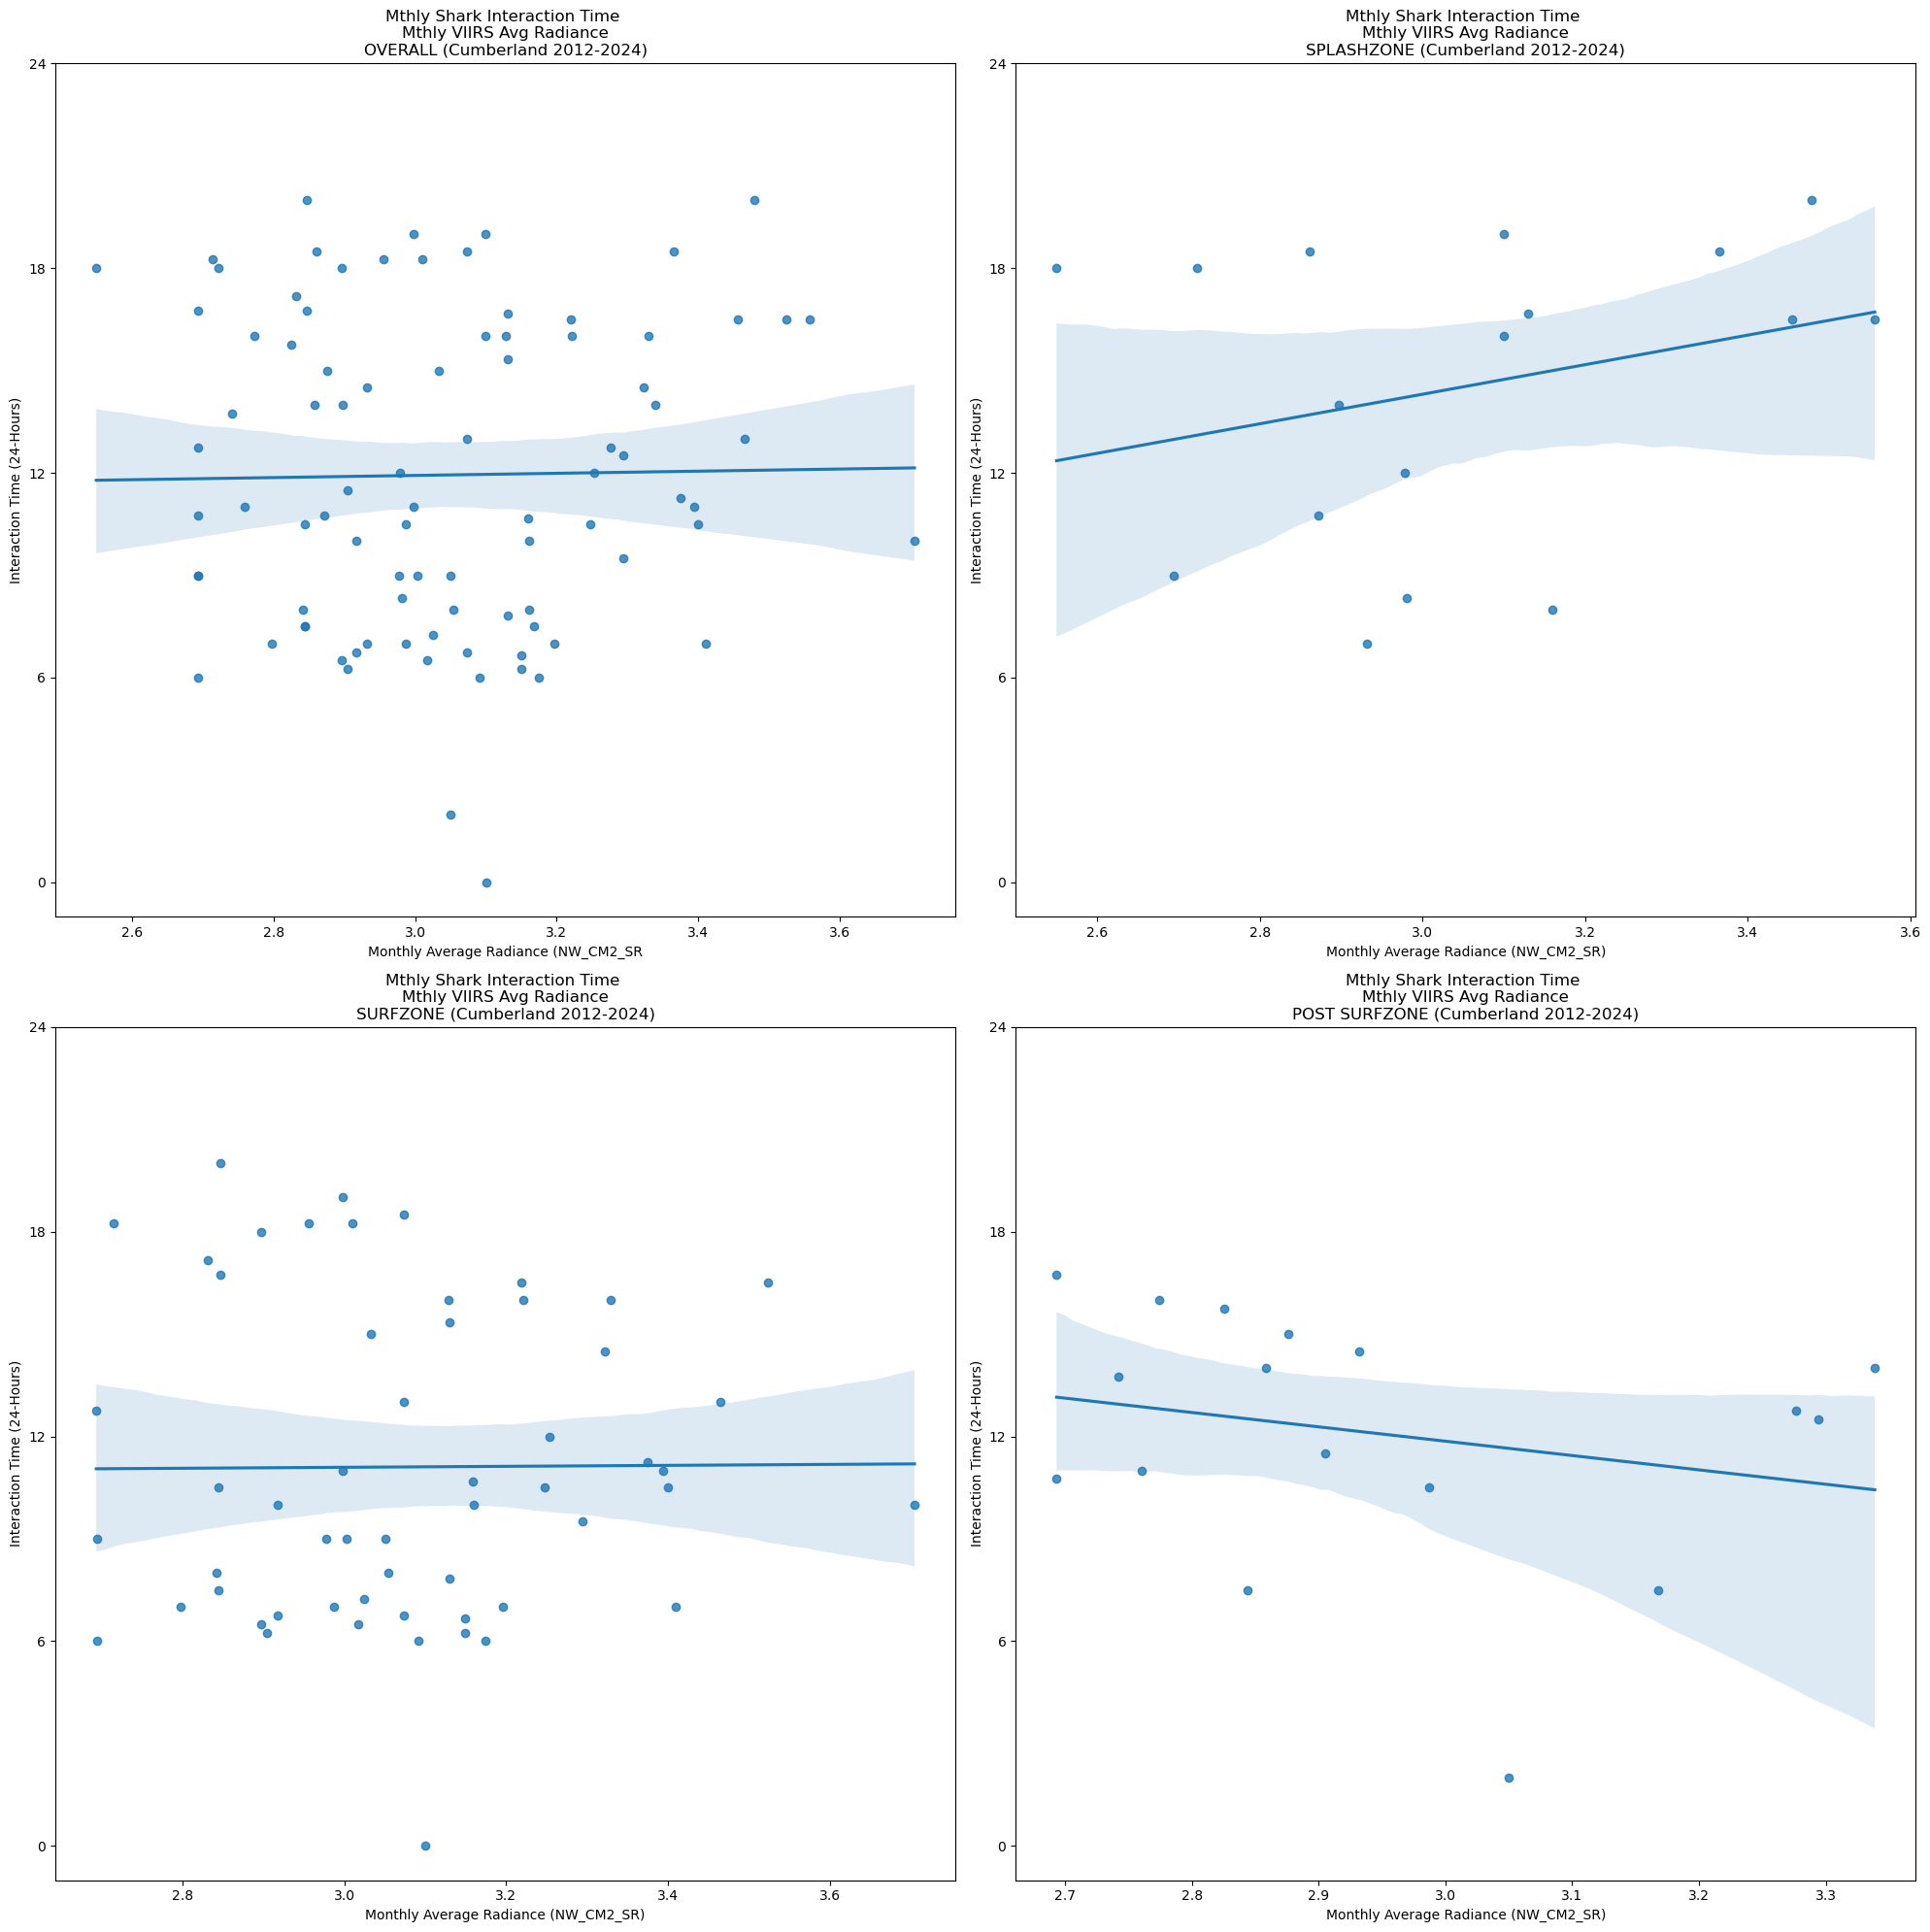

In [20]:
# plotting 4 linear regressions using loc that made separate dataframes for seaborn
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
sns.regplot(data = df9, x = 'MO_AVG_RAD_NW_CM2_SR', y = 'INTERACT_TIME', ax=axes[0,0])
axes[0,0].set_title('Mthly Shark Interaction Time \nMthly VIIRS Avg Radiance\nOVERALL (Cumberland 2012-2024)')
axes[0,0].set_xlabel('Monthly Average Radiance (NW_CM2_SR')
axes[0,0].set_ylabel('Interaction Time (24-Hours)')
axes[0,0].set_ylim(-1,24)
axes[0,0].set_yticks([0, 6, 12, 18, 24])


sns.regplot(data = df91, x = 'MO_AVG_RAD_NW_CM2_SR', y = 'INTERACT_TIME', ax=axes[0,1])
axes[0,1].set_title('Mthly Shark Interaction Time \nMthly VIIRS Avg Radiance\nSPLASHZONE (Cumberland 2012-2024)')
axes[0,1].set_xlabel('Monthly Average Radiance (NW_CM2_SR)')
axes[0,1].set_ylabel('Interaction Time (24-Hours)')
axes[0,1].set_ylim(-1,24)
axes[0,1].set_yticks([0, 6, 12, 18, 24])


sns.regplot(data = df92, x = 'MO_AVG_RAD_NW_CM2_SR', y = 'INTERACT_TIME', ax=axes[1,0])
axes[1,0].set_title('Mthly Shark Interaction Time \nMthly VIIRS Avg Radiance\nSURFZONE (Cumberland 2012-2024)')
axes[1,0].set_xlabel('Monthly Average Radiance (NW_CM2_SR)')
axes[1,0].set_ylabel('Interaction Time (24-Hours)')
axes[1,0].set_ylim(-1,24)
axes[1,0].set_yticks([0, 6, 12, 18, 24])


sns.regplot(data = df93, x = 'MO_AVG_RAD_NW_CM2_SR', y = 'INTERACT_TIME', ax=axes[1,1])
axes[1,1].set_title('Mthly Shark Interaction Time \nMthly VIIRS Avg Radiance\nPOST SURFZONE (Cumberland 2012-2024)')
axes[1,1].set_xlabel('Monthly Average Radiance (NW_CM2_SR)')
axes[1,1].set_ylabel('Interaction Time (24-Hours)')
axes[1,1].set_ylim(-1,24)
axes[1,1].set_yticks([0, 6, 12, 18, 24])

plt.tight_layout()
plt.show()

### F6: Dicussion 
The SplashZone shows a positive linear relationship, with interactions occurring later in the day as annual average nighttime light radiance increases; the SurfZone shows a neutral relationship; and the post-surfzone shows a negative relationship, with interactions occurring earlier in the day as annual average nighttime light radiance increases. The overall relationship is neutral and linear, with a seemingly unchanging pattern that does not align with our hypothesis that increased nighttime light shifts shark-human interactions toward the evening.

### Figure 7: Linear Regression of Monthly Shark Interaction Time over Monthly Average Radiance: Overall (VIIRS 2012-2024) Volusia County (Florida, USA): Overall, SplashZone & SurfZone

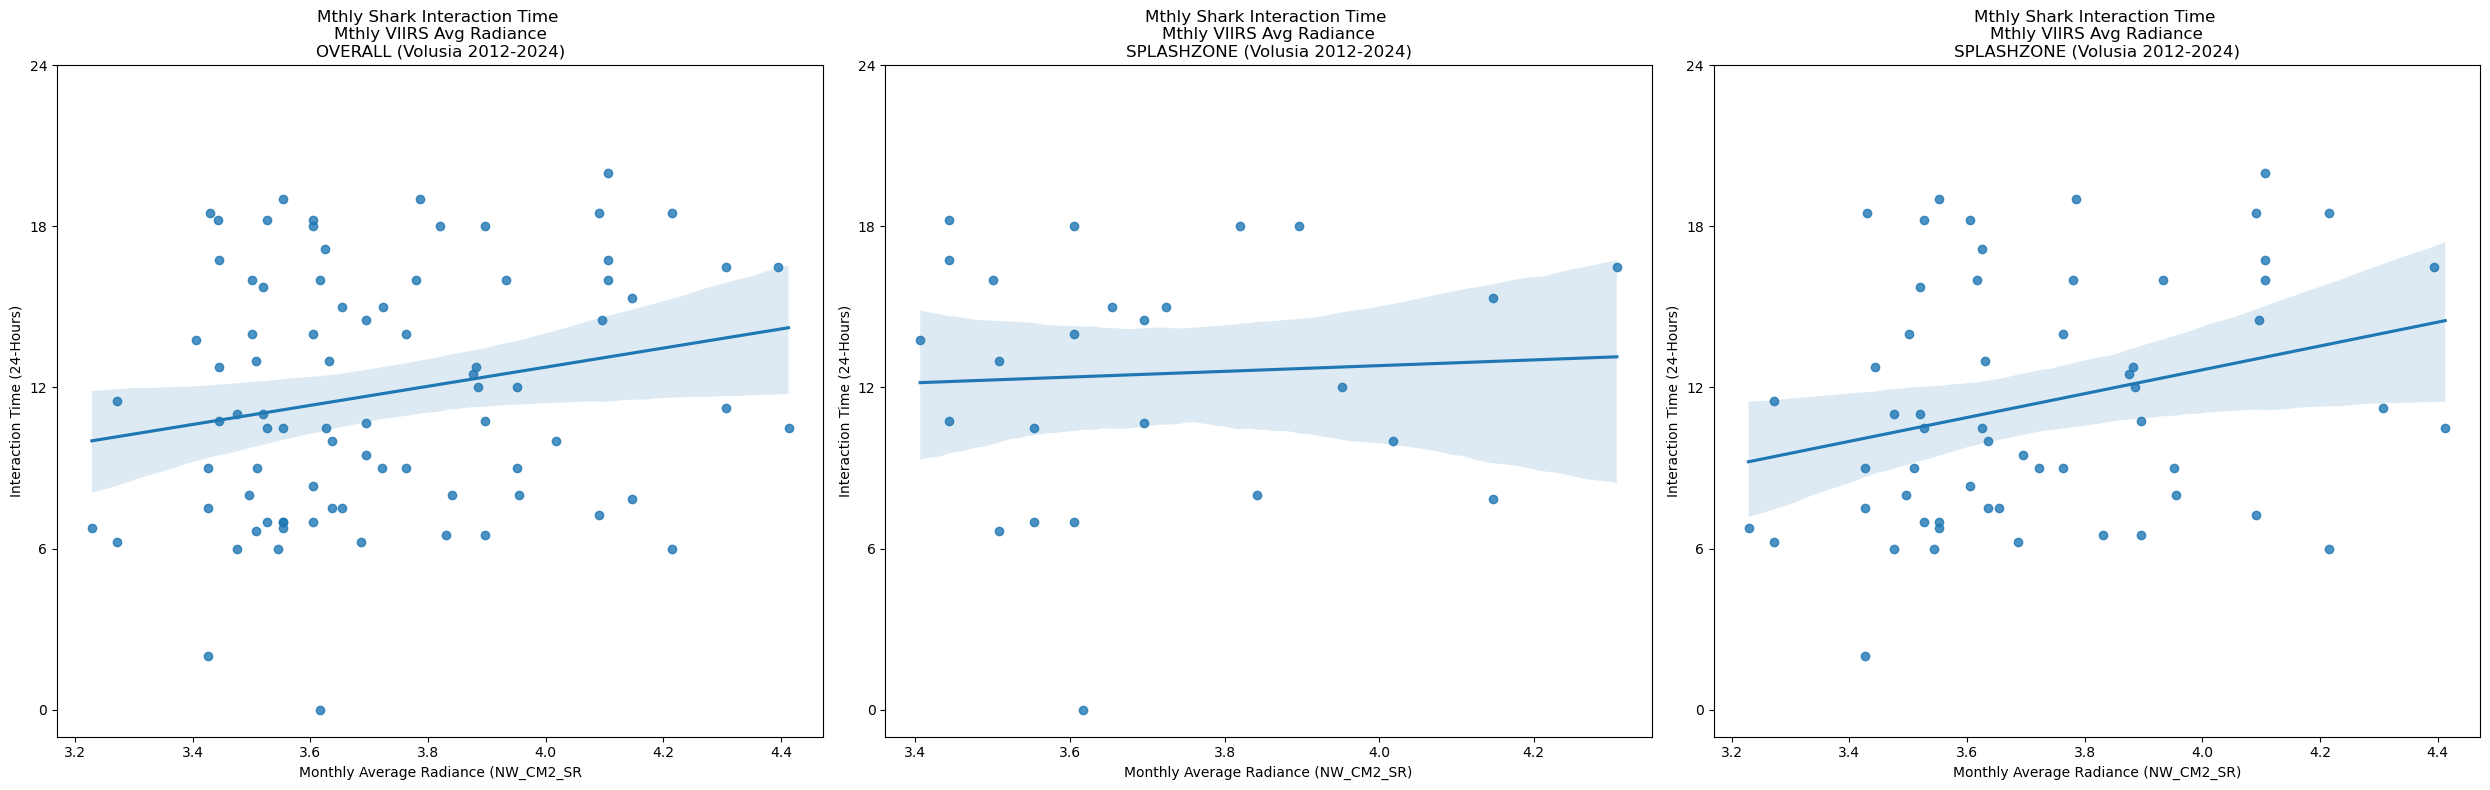

In [21]:
# plotting 4 linear regressions using loc that made separate dataframes for seaborn
fig, axes = plt.subplots(1, 3, figsize=(25, 8))
sns.regplot(data = df10, x = 'MO_AVG_RAD_NW_CM2_SR', y = 'INTERACT_TIME', ax=axes[0])
axes[0].set_title('Mthly Shark Interaction Time \nMthly VIIRS Avg Radiance\nOVERALL (Volusia 2012-2024)')
axes[0].set_xlabel('Monthly Average Radiance (NW_CM2_SR')
axes[0].set_ylabel('Interaction Time (24-Hours)')
axes[0].set_ylim(-1,24)
axes[0].set_yticks([0, 6, 12, 18, 24])


sns.regplot(data = df101, x = 'MO_AVG_RAD_NW_CM2_SR', y = 'INTERACT_TIME', ax=axes[1])
axes[1].set_title('Mthly Shark Interaction Time \nMthly VIIRS Avg Radiance\nSPLASHZONE (Volusia 2012-2024)')
axes[1].set_xlabel('Monthly Average Radiance (NW_CM2_SR)')
axes[1].set_ylabel('Interaction Time (24-Hours)')
axes[1].set_ylim(-1,24)
axes[1].set_yticks([0, 6, 12, 18, 24])


sns.regplot(data = df102, x = 'MO_AVG_RAD_NW_CM2_SR', y = 'INTERACT_TIME', ax=axes[2])
axes[2].set_title('Mthly Shark Interaction Time \nMthly VIIRS Avg Radiance\nSPLASHZONE (Volusia 2012-2024)')
axes[2].set_xlabel('Monthly Average Radiance (NW_CM2_SR)')
axes[2].set_ylabel('Interaction Time (24-Hours)')
axes[2].set_ylim(-1,24)
axes[2].set_yticks([0, 6, 12, 18, 24])

plt.tight_layout()
plt.show()

### F7: Dicussion 

Overall, SplashZone & SurfZone have a slight positive linear relationship, with interactions occurring later in the day as annual average nighttime light radiance increases. This aligns with our hypothesis that increased nighttime light shifts shark-human interactions toward the evening, and it also indicates a very weak relationship.

Interestingly, these results are the opposite of what we found when examining annual DN nighttime light and shark interactions, which showed a negative linear relationship: interactions occurred earlier in the day as annual DN nighttime light increased. The discrepancy between this and the DN nighttime light figures and the first one may be due to the use of different units



### Overall Limitions & Take Aways

One of the main limitations is the discrete nature of the data, since regression analyses respond better to continuous data that can reveal subtle trends, whereas discrete data focus on strong trends. In addition to running a regression over time, I had to integrate it with the seaborn tool I used. Also, we are only looking at around 20 years of data.

Overall their are interesting takeaways with the DSMP (1992-2013) & VIIRS (2012-2024) data having opposite relationships, particularly with the annual nighttime light over shark interaction count scatter plot figures, and for both Cumberland and Volusia, and again in both of the time series between Figures 4 & 5 compared to Figures 6 & 7. It makes me wonder whether this is due to how the nighttime light was calculated, since the DSMP is not as accurate as VIIRS; if it were, would the results be the same?

Overall, the DSMP data in Figure 1 aligned with our hypothesis  that more nighttime light may increase shark-human interactions, and inversely, the VIIRS data in Figure 6 (the splashzone and negligibly the overall & surfzone) and the overall, splashzone & surfzone plots in Figure 7 aligned with our hypothesis that increased nighttime light shifts shark-human interactions to occur in the evening